In [15]:
# Importing required libraries and csv files

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

monthly = pd.read_csv('monthly_summary.csv', parse_dates=['Month'], index_col = 'Month')
category_breakdown = pd.read_csv('category_breakdown.csv', index_col = 'Category').squeeze()

month_labels = monthly.index.strftime('%b')

In [16]:
monthly.head()

,Total_income,Total_expense,Total_savings,Savings_Rate(%),Running_balance
Month,,,,,
2024-01-01,53000.0,25200.0,27800.0,52.45,27800.0
2024-02-01,50000.0,26200.0,23800.0,47.60,51600.0
2024-03-01,57000.0,27000.0,29000.0,50.88,80600.0
2024-04-01,51500.0,27800.0,23700.0,46.02,104300.0
2024-05-01,57000.0,25100.0,31900.0,55.96,136200.0


In [17]:
category_breakdown.head()

Category
Entertainment    18000.0
Health           21000.0
Utilities        28500.0
Transport        31900.0
Food             86000.0
Name: Amount, dtype: float64

#### Build the bar chart and pie chart

##### Bar chart — expenses by category

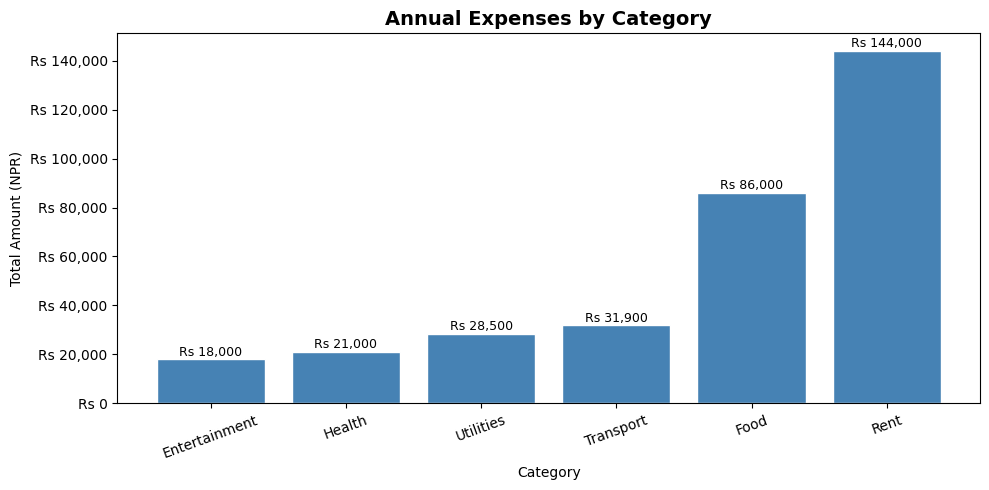

Bar chart saved!


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(category_breakdown.index, category_breakdown.values, color='steelblue', edgecolor='white')

# Add value labels on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'Rs {bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Annual Expenses by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Amount (NPR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs {x:,.0f}'))
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('chart1_expenses_bar.png', dpi=150)
plt.show()
print("Bar chart saved!")

##### Pie chart — savings vs total spending

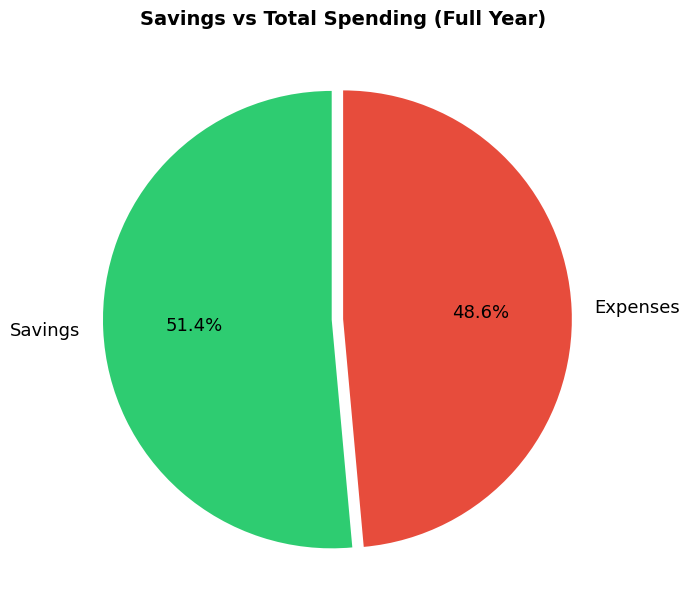

Pie chart saved!


In [20]:
total_savings = monthly['Total_savings'].sum()
total_expenses = monthly['Total_expense'].sum()

labels = ['Savings', 'Expenses']
values = [total_savings, total_expenses]
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    values, labels=labels, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13}
)
ax.set_title('Savings vs Total Spending (Full Year)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_savings_pie.png', dpi=150)
plt.show()
print("Pie chart saved!")